# Experiment 12: PFA Comparison — Additive Q-Matrix as Enhanced (Run 3)

Same structure as Experiment 09 but **Run 3 = additive Q-matrix** from Experiment 10b
(additive-only LLM refinement: instructor tags preserved, only additions allowed).

| Run | KC Model | Source |
|-----|----------|--------|
| 1 | KCGen-KT LLM | `dataset/kcgen-kt/problem_kc.json` |
| 2 | Instructor | `dataset/CodeWorkout/Problem_Prompts/problem_prompts.csv` |
| 3 | **Additive (10b)** | `results/10_qmatrix_refinement/additive_problem_prompts.csv` |

**Research question:** Does additive-only refinement (which can't remove KCs) improve on
the instructor baseline, unlike 10a which hurt AUC by over-pruning?

In [1]:
import pandas as pd
import numpy as np
import json
import os
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

N_FOLDS = 5
RANDOM_SEED = 42

print("=" * 70)
print("Experiment 12 — PFA Comparison with Additive Q-Matrix")
print("=" * 70)

Experiment 12 — PFA Comparison with Additive Q-Matrix


## Load and prepare data

In [2]:
mt = pd.read_csv("dataset/CodeWorkout/MainTable.csv")
print(f"Raw MainTable: {len(mt)} rows, {mt['SubjectID'].nunique()} students, {mt['ProblemID'].nunique()} problems")

mt = mt[mt['EventType'] == 'Run.Program'].copy()
mt = mt.dropna(subset=['Score'])
mt['ServerTimestamp'] = pd.to_datetime(mt['ServerTimestamp'])
mt.sort_values(['SubjectID', 'ServerTimestamp'], inplace=True)
mt['correct'] = (mt['Score'] == 1.0).astype(int)

first_attempts = mt.drop_duplicates(subset=['SubjectID', 'ProblemID'], keep='first').copy()
first_attempts = first_attempts.reset_index(drop=True)

print(f"First attempts: {len(first_attempts)} rows, {first_attempts['SubjectID'].nunique()} students, {first_attempts['ProblemID'].nunique()} problems")
print(f"Correct rate: {first_attempts['correct'].mean():.3f}")

Raw MainTable: 201570 rows, 413 students, 50 problems
First attempts: 16179 rows, 413 students, 50 problems
Correct rate: 0.403


## Load three KC models

In [3]:
pp = pd.read_csv("dataset/CodeWorkout/Problem_Prompts/problem_prompts.csv")
kc_cols = list(pp.columns)[3:]  # 18 KC columns

requirement_to_pid = dict(zip(pp['Requirement'], pp['ProblemID']))

# --- KC Model 1: KCGen-KT LLM-generated KCs ---
with open("dataset/kcgen-kt/problem_kc.json") as f:
    kcgen_raw = json.load(f)

kcgen_kc_map = {}
unmatched = 0
for req_text, kc_list in kcgen_raw.items():
    pid = requirement_to_pid.get(req_text)
    if pid is None:
        for req, p in requirement_to_pid.items():
            if req[:100] == req_text[:100]:
                pid = p
                break
    if pid is not None:
        kc_names = []
        for item in kc_list:
            if isinstance(item, list) and len(item) >= 2:
                kc_names.append(item[1])
            elif isinstance(item, str):
                kc_names.append(item)
        kcgen_kc_map[pid] = list(set(kc_names))
    else:
        unmatched += 1

kcgen_all_kcs = sorted(set(kc for kcs in kcgen_kc_map.values() for kc in kcs))
print(f"KC Model 1 (KCGen-KT LLM): {len(kcgen_all_kcs)} unique KCs, {len(kcgen_kc_map)} problems mapped, {unmatched} unmatched")

# --- KC Model 2: Instructor KCs ---
instructor_kc_map = {}
for _, row in pp.iterrows():
    pid = row['ProblemID']
    kcs = [kc_cols[i] for i, v in enumerate(row[3:]) if v == 1]
    instructor_kc_map[pid] = kcs

instructor_all_kcs = sorted(kc_cols)
print(f"KC Model 2 (Instructor): {len(instructor_all_kcs)} unique KCs, {len(instructor_kc_map)} problems mapped")

# --- KC Model 3: Additive Q-matrix from Experiment 10b ---
ADDITIVE_PATH = "results/10_qmatrix_refinement/additive_problem_prompts.csv"
if os.path.exists(ADDITIVE_PATH):
    additive_pp = pd.read_csv(ADDITIVE_PATH)
    all_kcs_18 = list(additive_pp.columns[1:])  # everything after ProblemID
    additive_kc_map = {}
    for _, row in additive_pp.iterrows():
        pid = row['ProblemID']
        kcs = [kc for kc in all_kcs_18 if row[kc] == 1]
        additive_kc_map[pid] = kcs
    additive_all_kcs = sorted(set(kc for kcs in additive_kc_map.values() for kc in kcs))
    print(f"KC Model 3 (Additive 10b): {len(additive_all_kcs)} unique KCs, {len(additive_kc_map)} problems mapped")
else:
    print(f"WARNING: {ADDITIVE_PATH} not found. Run Experiment 11 first.")
    additive_kc_map = instructor_kc_map.copy()
    additive_all_kcs = instructor_all_kcs.copy()

KC Model 1 (KCGen-KT LLM): 11 unique KCs, 50 problems mapped, 0 unmatched
KC Model 2 (Instructor): 18 unique KCs, 50 problems mapped
KC Model 3 (Additive 10b): 18 unique KCs, 49 problems mapped


## Build PFA features and run cross-validation

In [4]:
def build_pfa_features(submissions_df, kc_map, all_kcs):
    """Build PFA features: prior success/failure counts per KC for each submission."""
    kc_to_idx = {kc: i for i, kc in enumerate(all_kcs)}
    n_kcs = len(all_kcs)

    X_rows, y_rows, student_ids = [], [], []
    skipped = 0

    for student_id, student_df in submissions_df.groupby('SubjectID'):
        success_counts = np.zeros(n_kcs)
        failure_counts = np.zeros(n_kcs)

        for _, row in student_df.iterrows():
            pid = row['ProblemID']
            correct = row['correct']

            if pid not in kc_map or len(kc_map[pid]) == 0:
                skipped += 1
                continue

            problem_kcs = kc_map[pid]
            feature_vec = np.zeros(2 * n_kcs)
            for kc in problem_kcs:
                if kc in kc_to_idx:
                    idx = kc_to_idx[kc]
                    feature_vec[2 * idx] = success_counts[idx]
                    feature_vec[2 * idx + 1] = failure_counts[idx]

            X_rows.append(feature_vec)
            y_rows.append(correct)
            student_ids.append(student_id)

            for kc in problem_kcs:
                if kc in kc_to_idx:
                    idx = kc_to_idx[kc]
                    if correct == 1:
                        success_counts[idx] += 1
                    else:
                        failure_counts[idx] += 1

    if skipped > 0:
        print(f"  Skipped {skipped} submissions (no KC mapping)")

    return np.array(X_rows), np.array(y_rows), student_ids


def run_pfa_cv(X, y, student_ids, n_folds=5, seed=42):
    """Run PFA (logistic regression) with student-level stratified K-fold CV."""
    unique_students = list(set(student_ids))
    sid_array = np.array(student_ids)

    student_avg = {s: y[sid_array == s].mean() for s in unique_students}
    student_labels = np.array([1 if student_avg[s] >= 0.5 else 0 for s in unique_students])

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    aucs, f1s, accs = [], [], []

    for fold, (train_idx, test_idx) in enumerate(skf.split(unique_students, student_labels), 1):
        train_students = set(np.array(unique_students)[train_idx])
        test_students = set(np.array(unique_students)[test_idx])

        train_mask = np.array([s in train_students for s in student_ids])
        test_mask = np.array([s in test_students for s in student_ids])

        model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed)
        model.fit(X[train_mask], y[train_mask])

        y_prob = model.predict_proba(X[test_mask])[:, 1]
        y_pred = model.predict(X[test_mask])

        aucs.append(roc_auc_score(y[test_mask], y_prob))
        f1s.append(f1_score(y[test_mask], y_pred))
        accs.append(accuracy_score(y[test_mask], y_pred))
        print(f"  Fold {fold}: AUC={aucs[-1]:.4f}, F1={f1s[-1]:.4f}, Acc={accs[-1]:.4f}")

    return {
        'AUC': (np.mean(aucs), np.std(aucs)),
        'F1': (np.mean(f1s), np.std(f1s)),
        'Accuracy': (np.mean(accs), np.std(accs)),
        'per_fold_auc': aucs,
    }


print("Building PFA features...")

print(f"\nKC Model 1 (KCGen-KT LLM, {len(kcgen_all_kcs)} KCs):")
X1, y1, sids1 = build_pfa_features(first_attempts, kcgen_kc_map, kcgen_all_kcs)
print(f"  X shape: {X1.shape}")

print(f"\nKC Model 2 (Instructor, {len(instructor_all_kcs)} KCs):")
X2, y2, sids2 = build_pfa_features(first_attempts, instructor_kc_map, instructor_all_kcs)
print(f"  X shape: {X2.shape}")

print(f"\nKC Model 3 (Additive 10b, {len(additive_all_kcs)} KCs):")
X3, y3, sids3 = build_pfa_features(first_attempts, additive_kc_map, additive_all_kcs)
print(f"  X shape: {X3.shape}")

Building PFA features...

KC Model 1 (KCGen-KT LLM, 11 KCs):
  X shape: (16179, 22)

KC Model 2 (Instructor, 18 KCs):
  X shape: (16179, 36)

KC Model 3 (Additive 10b, 18 KCs):
  Skipped 339 submissions (no KC mapping)
  X shape: (15840, 36)


In [5]:
print("=" * 70)
print("Running PFA Cross-Validation")
print("=" * 70)

print(f"\n--- Run 1: KCGen-KT LLM KCs ({len(kcgen_all_kcs)} KCs) ---")
results_1 = run_pfa_cv(X1, y1, sids1, N_FOLDS, RANDOM_SEED)

print(f"\n--- Run 2: Instructor KCs ({len(instructor_all_kcs)} KCs) ---")
results_2 = run_pfa_cv(X2, y2, sids2, N_FOLDS, RANDOM_SEED)

print(f"\n--- Run 3: Additive KCs ({len(additive_all_kcs)} KCs) ---")
results_3 = run_pfa_cv(X3, y3, sids3, N_FOLDS, RANDOM_SEED)

Running PFA Cross-Validation

--- Run 1: KCGen-KT LLM KCs (11 KCs) ---
  Fold 1: AUC=0.7596, F1=0.5615, Acc=0.7078
  Fold 2: AUC=0.7626, F1=0.5386, Acc=0.7163
  Fold 3: AUC=0.7652, F1=0.5603, Acc=0.7132
  Fold 4: AUC=0.7438, F1=0.5487, Acc=0.6997
  Fold 5: AUC=0.7553, F1=0.5527, Acc=0.7092

--- Run 2: Instructor KCs (18 KCs) ---
  Fold 1: AUC=0.7805, F1=0.5923, Acc=0.7224
  Fold 2: AUC=0.7795, F1=0.5889, Acc=0.7344
  Fold 3: AUC=0.7744, F1=0.5862, Acc=0.7192
  Fold 4: AUC=0.7623, F1=0.5818, Acc=0.7097
  Fold 5: AUC=0.7720, F1=0.5903, Acc=0.7217

--- Run 3: Additive KCs (18 KCs) ---
  Fold 1: AUC=0.7713, F1=0.5775, Acc=0.7184
  Fold 2: AUC=0.7699, F1=0.5738, Acc=0.7112
  Fold 3: AUC=0.7672, F1=0.5757, Acc=0.7163
  Fold 4: AUC=0.7905, F1=0.5996, Acc=0.7417
  Fold 5: AUC=0.7529, F1=0.5710, Acc=0.7145


## Results summary

In [6]:
print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

print(f"\n{'KC Model':<40} {'AUC':>14} {'F1':>14} {'Accuracy':>14}")
print("-" * 85)

all_results = [
    (f"KCGen-KT LLM ({len(kcgen_all_kcs)} KCs)", results_1),
    (f"Instructor ({len(instructor_all_kcs)} KCs)", results_2),
    (f"Additive/10b ({len(additive_all_kcs)} KCs)", results_3),
]

for name, res in all_results:
    auc_m, auc_s = res['AUC']
    f1_m, f1_s = res['F1']
    acc_m, acc_s = res['Accuracy']
    print(f"{name:<40} {auc_m:.4f}±{auc_s:.4f} {f1_m:.4f}±{f1_s:.4f} {acc_m:.4f}±{acc_s:.4f}")

# Save to CSV
results_df = pd.DataFrame([
    {
        'KC_Model': name,
        'Num_KCs': len(kcgen_all_kcs) if 'LLM' in name else (len(additive_all_kcs) if 'Additive' in name else len(instructor_all_kcs)),
        'AUC_mean': res['AUC'][0], 'AUC_std': res['AUC'][1],
        'F1_mean': res['F1'][0], 'F1_std': res['F1'][1],
        'Acc_mean': res['Accuracy'][0], 'Acc_std': res['Accuracy'][1],
    }
    for name, res in all_results
])
results_df.to_csv('12_pfa_additive_results.csv', index=False)
print("\nSaved to 12_pfa_additive_results.csv")


RESULTS SUMMARY

KC Model                                            AUC             F1       Accuracy
-------------------------------------------------------------------------------------
KCGen-KT LLM (11 KCs)                    0.7573±0.0075 0.5524±0.0084 0.7092±0.0057
Instructor (18 KCs)                      0.7737±0.0065 0.5879±0.0037 0.7215±0.0079
Additive/10b (18 KCs)                    0.7703±0.0120 0.5795±0.0103 0.7204±0.0109

Saved to 12_pfa_additive_results.csv


## Statistical significance

In [7]:
print("\n--- Statistical Significance (paired t-test on per-fold AUC) ---\n")

comparisons = [
    ("KCGen-KT LLM", results_1, "Instructor", results_2),
    ("Instructor", results_2, "Additive/10b", results_3),
    ("KCGen-KT LLM", results_1, "Additive/10b", results_3),
]

for name_a, res_a, name_b, res_b in comparisons:
    t_stat, p_val = stats.ttest_rel(res_a['per_fold_auc'], res_b['per_fold_auc'])
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    delta = np.mean(res_a['per_fold_auc']) - np.mean(res_b['per_fold_auc'])
    print(f"  {name_a} vs {name_b}:")
    print(f"    ΔAUC = {delta:+.4f}, t = {t_stat:.3f}, p = {p_val:.4f} [{sig}]")
    print()


--- Statistical Significance (paired t-test on per-fold AUC) ---

  KCGen-KT LLM vs Instructor:
    ΔAUC = -0.0164, t = -8.376, p = 0.0011 [**]

  Instructor vs Additive/10b:
    ΔAUC = +0.0034, t = 0.417, p = 0.6981 [ns]

  KCGen-KT LLM vs Additive/10b:
    ΔAUC = -0.0130, t = -1.488, p = 0.2109 [ns]



## Visualization

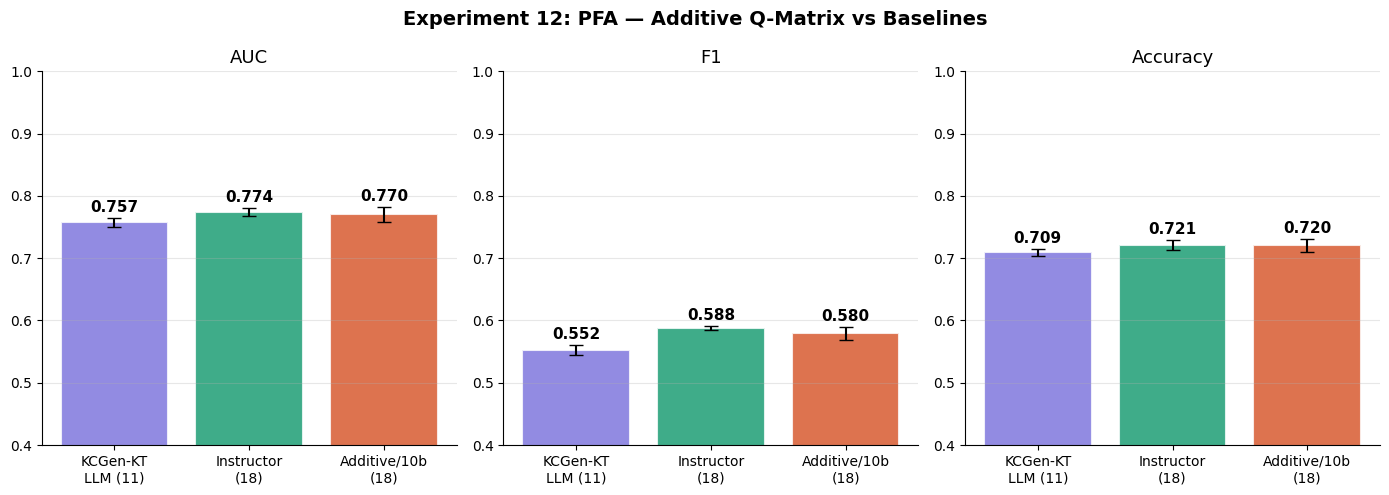

Saved: 12_pfa_additive_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Experiment 12: PFA — Additive Q-Matrix vs Baselines', fontsize=14, fontweight='bold')

metrics = ['AUC', 'F1', 'Accuracy']
model_names = [
    f'KCGen-KT\nLLM ({len(kcgen_all_kcs)})',
    f'Instructor\n({len(instructor_all_kcs)})',
    f'Additive/10b\n({len(additive_all_kcs)})',
]
colors = ['#7F77DD', '#1D9E75', '#D85A30']
result_list = [results_1, results_2, results_3]

for ax, metric in zip(axes, metrics):
    means = [r[metric][0] for r in result_list]
    stds = [r[metric][1] for r in result_list]

    bars = ax.bar(model_names, means, yerr=stds, capsize=5,
                  color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0.4, 1.0)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('12_pfa_additive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 12_pfa_additive_comparison.png")

## Per-KC PFA parameters (additive model)

Fit final model on all data to inspect learned γ (success) and ρ (failure) weights.

In [9]:
final_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=RANDOM_SEED)
final_model.fit(X3, y3)

coefs = final_model.coef_[0]
print("Additive KC PFA Parameters (learned weights):")
print(f"\n{'KC':<20} {'γ (success)':>12} {'ρ (failure)':>12} {'Interpretation'}")
print("-" * 70)

for i, kc in enumerate(additive_all_kcs):
    gamma = coefs[2 * i]
    rho = coefs[2 * i + 1]

    if gamma > 0.1:
        interp = "Practice helps a lot"
    elif gamma > 0:
        interp = "Practice helps slightly"
    elif rho < -0.1:
        interp = "Failures hurt — hard KC"
    else:
        interp = "Weak signal"

    # Mark KCs that were added by the LLM (not in instructor set)
    tag = " [ADDED]" if kc not in instructor_all_kcs else ""
    print(f"{kc:<20} {gamma:>12.4f} {rho:>12.4f}   {interp}{tag}")

print(f"\nIntercept (baseline difficulty): {final_model.intercept_[0]:.4f}")

Additive KC PFA Parameters (learned weights):

KC                    γ (success)  ρ (failure) Interpretation
----------------------------------------------------------------------
ArrayIndex                -0.0178      -0.0542   Weak signal
CharEqual                 -0.1189      -0.0411   Weak signal
DefFunction                0.3942      -0.0270   Practice helps a lot
For                        0.1651       0.0484   Practice helps a lot
If/Else                    0.0141      -0.0407   Practice helps slightly
LogicAndNotOr             -0.0275      -0.0072   Weak signal
LogicBoolean               0.0820      -0.0121   Practice helps slightly
LogicCompareNum            0.0230      -0.0139   Practice helps slightly
Math%                      0.0366       0.0818   Practice helps slightly
Math+-*/                   0.0593      -0.0329   Practice helps slightly
NestedFor                 -0.5172      -0.2157   Failures hurt — hard KC
NestedIf                   0.2603       0.0598   Practice h